In [201]:
import scipy as sp
from scipy.special import jv, hankel2, yv, spherical_jn, spherical_yn
import numpy as np
import matplotlib.pyplot as plt
from numpy import sqrt, linspace, zeros, ones, argmin, log, unravel_index, pi, array
from utils import e_r_cpa_numerator, e_r_cpa_denominator, e_r_cpa, hl2, hl2prime, hl1, hl1prime
from refractiveindex import RefractiveIndexMaterial

## We try to re-create Figure 2 of the paper

In [5]:
omega_p = 7.9 # Bulk plasma frequency of Gold in eV
hbar_c = 6.58211957 * 3 * 10 #200 # in nanometers * eV

In [164]:
def gold_drude(omega_over_omega_p, omega_p=7.9, gamma_e=0.09):
    return 1-1/(omega_over_omega_p*(omega_over_omega_p+1j*gamma_e/omega_p))

In [599]:
R_lindependent = 6
void_upper_lims = [0.5, 0.65, 0.7]
void_lower_lims = [0.2, 0.4, 0.5]

sphere_upper_lims = [0.2, 0.4, 0.5]
sphere_lower_lims = [0.01, 0.18, 0.3]

void_omegas = []
sphere_omegas = []

ls = [1, 2, 3]
epsilon = 1
gamma_e = 0

K = 200
N = 200
Hs_lindependent = linspace(0.1, 0.8, K)

heatmaps_void = [] 
heatmaps_sphere = [] 

for (l_idx, l) in enumerate(ls):
    void_lower_limit = void_lower_lims[l_idx]
    void_upper_limit = void_upper_lims[l_idx]
    R = R_lindependent * l 
    Hs = l * Hs_lindependent
    Hs_reshaped = Hs.reshape((K, 1)).repeat(N, axis=1)
    omega_over_omega_ps_real = linspace(void_lower_limit, void_upper_limit, N)# range of real(omega)/omega_p
    omega_over_omega_ps_real_reshaped = omega_over_omega_ps_real.reshape((1, N)).repeat(K, axis=0)
    g_omegas = (gold_drude(omega_over_omega_ps_real_reshaped, gamma_e=gamma_e)-1) * Hs_reshaped/R
    kR = R * omega_over_omega_ps_real_reshaped
    thin_film_approx = e_r_cpa_denominator(l, kR, epsilon, g_omegas=g_omegas);
    void_omegas.append(omega_over_omega_ps_real[np.abs(thin_film_approx).argmin(axis=1)])
    heatmaps_void.append(thin_film_approx)
    sphere_lower_limit = sphere_lower_lims[l_idx]
    sphere_upper_limit = sphere_upper_lims[l_idx]
    omega_over_omega_ps_real = linspace(sphere_lower_limit, sphere_upper_limit, N) # range of real(omega)/omega_p
    omega_over_omega_ps_real_reshaped = omega_over_omega_ps_real.reshape((1, N)).repeat(K, axis=0)
    g_omegas = (gold_drude(omega_over_omega_ps_real_reshaped, gamma_e=gamma_e)-1) * Hs_reshaped/R
    kR = R * omega_over_omega_ps_real_reshaped
    thin_film_approx = e_r_cpa_denominator(l, kR, epsilon, g_omegas=g_omegas);
    sphere_omegas.append(omega_over_omega_ps_real[np.abs(thin_film_approx).argmin(axis=1)])
    heatmaps_sphere.append(thin_film_approx)

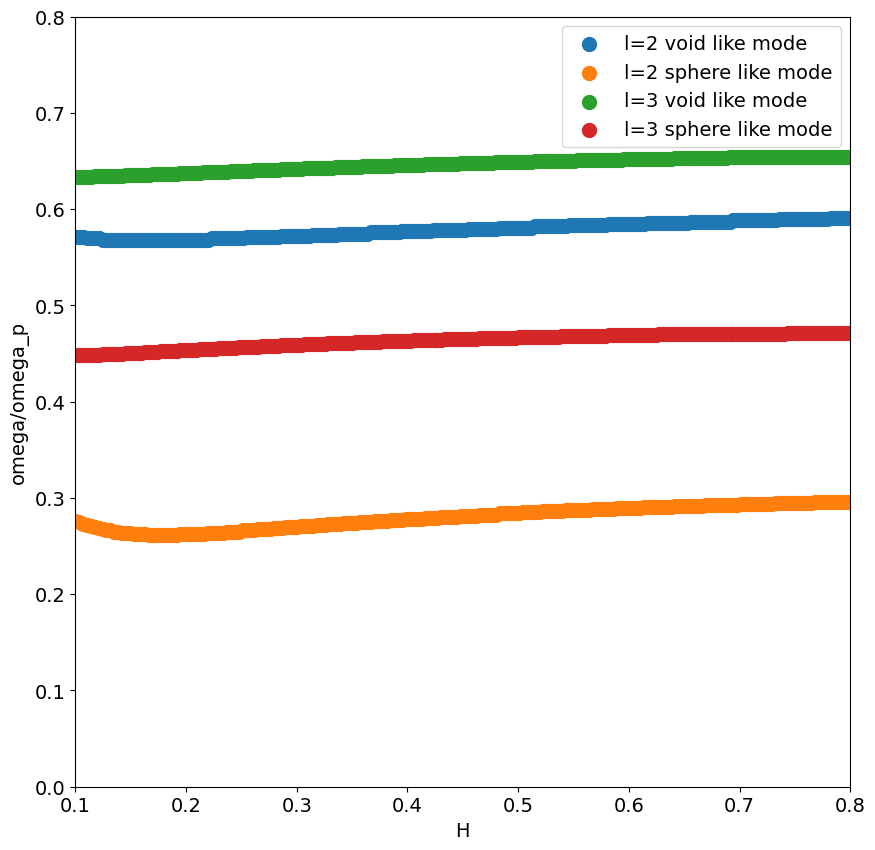

In [603]:
color="green"
fig, ax = plt.subplots(figsize=(10, 10))
for (l_idx, l) in enumerate(ls):
    if l == 1:
        continue
    plt.scatter(Hs_lindependent, void_omegas[l_idx], s=100, label=f"l={l} void like mode" )
    plt.scatter(Hs_lindependent, sphere_omegas[l_idx], s=100, label=f"l={l} sphere like mode" )
plt.legend()
plt.ylim(0, 0.8)
plt.xlim(0.1, 0.8);
plt.xlabel("H")
plt.ylabel("omega/omega_p");